In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("flats_missing_val.csv")

In [3]:
df.head()

,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,...,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,...,1,1,1,0,0,0,135.0,37,3.0,New Property
1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,...,1,1,0,0,0,1,150.0,31,3.0,New Property
2,Askari,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,8.0,3.55,10.0,2720.0,1.0,1.0,...,1,1,1,1,1,1,156.0,49,3.0,New Property
3,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,8.0,4.45,7.6,2067.2,1.0,2.0,...,1,0,0,0,0,1,125.0,18,3.0,New Property
4,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,...,1,1,0,0,0,1,100.0,18,3.0,New Property


In [4]:
df.columns

Index(['society', 'bedrooms', 'baths', 'link', 'floors_in_building', 'price',
       'area', 'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'luxury_score',
       'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

In [5]:
drop_cols = [
    'link',
    'society',
    'area',
    'price_per_sqft'
]

train_df=df.drop(columns=drop_cols)

In [6]:
train_df.head()

,bedrooms,baths,floors_in_building,price,area_sqft,servant_quarters,kitchens,store_rooms,drawing_room,dining_room,...,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,4.0,4.0,9.0,4.55,3264.0,1.0,1.0,1.0,1,1,...,1,1,1,0,0,0,135.0,37,3.0,New Property
1,4.0,5.0,10.0,4.50,3318.4,1.0,1.0,0.0,1,1,...,1,1,0,0,0,1,150.0,31,3.0,New Property
2,3.0,4.0,8.0,3.55,2720.0,1.0,1.0,1.0,1,1,...,1,1,1,1,1,1,156.0,49,3.0,New Property
3,4.0,4.0,8.0,4.45,2067.2,1.0,2.0,1.0,1,1,...,1,0,0,0,0,1,125.0,18,3.0,New Property
4,4.0,5.0,10.0,4.65,3318.4,1.0,1.0,1.0,1,1,...,1,1,0,0,0,1,100.0,18,3.0,New Property


In [7]:
train_df.columns

Index(['bedrooms', 'baths', 'floors_in_building', 'price', 'area_sqft',
       'servant_quarters', 'kitchens', 'store_rooms', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

<Axes: xlabel='luxury_score'>

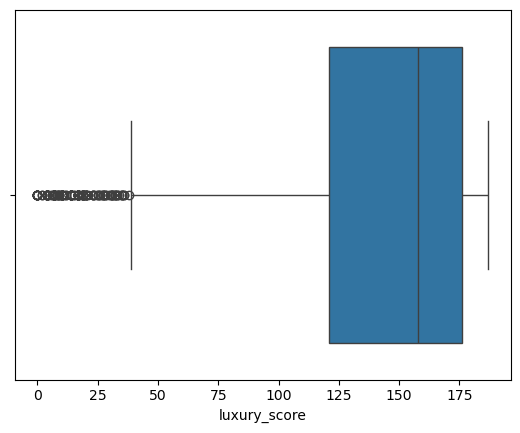

In [8]:
sns.boxplot(x=df['luxury_score'])

In [9]:
def categorize_luxury(score):
    if score < 120:
        return "Low"
    elif 120 <= score < 155:
        return "Medium"
    elif 155 <= score < 175:
        return "High"
    else:
        return "Very High"

| Range    | Category                     |
| -------- | ---------------------------- |
| Lowest   | Budget                       |
| Mid-low  | Semi-Luxury                  |
| Mid-high | Luxury                       |
| Highest  | **Ultra Luxury / Premium** ⭐ |


In [10]:
q1 = train_df['luxury_score'].quantile(0.25)
q2 = train_df['luxury_score'].quantile(0.50)
q3 = train_df['luxury_score'].quantile(0.75)

def categorize_luxury(score):
    if score < q1:
        return "Low"
    elif score < q2:
        return "Medium"
    elif score < q3:
        return "High"
    else:
        return "Very High"


In [11]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

<Axes: xlabel='floor'>

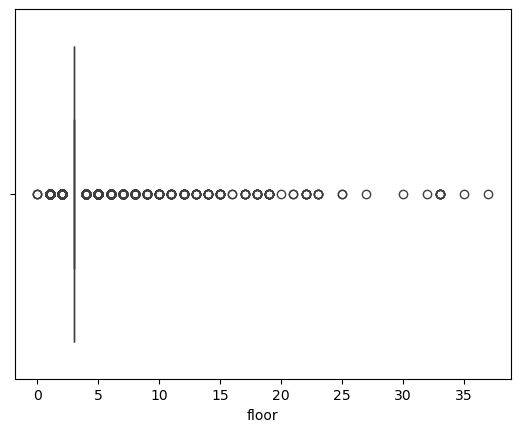

In [12]:
sns.boxplot(x=df['floor'])

In [13]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif floor >= 11:
        return "High Floor"
    else:
        return None

train_df['floor_category'] = train_df['floor'].apply(categorize_floor)

In [14]:
train_df['floor_category'].value_counts()

floor_category
Mid Floor     2390
Low Floor      526
High Floor     118
Name: count, dtype: int64

In [15]:
train_df.drop(columns=['floor', 'luxury_score'], inplace=True)

In [16]:
train_df.columns

Index(['bedrooms', 'baths', 'floors_in_building', 'price', 'area_sqft',
       'servant_quarters', 'kitchens', 'store_rooms', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'furnishing_score', 'agePossession', 'luxury_category',
       'floor_category'],
      dtype='object')

In [17]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()

categorical_cols = data_label_encoded.select_dtypes(include=['object']).columns

oe = OrdinalEncoder()
data_label_encoded[categorical_cols] = oe.fit_transform(data_label_encoded[categorical_cols])

X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [18]:
X_label

,bedrooms,baths,floors_in_building,area_sqft,servant_quarters,kitchens,store_rooms,drawing_room,dining_room,lounge_or_sitting_room,...,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,furnishing_score,agePossession,luxury_category,floor_category
0,4.0,4.0,9.0,3264.0,1.0,1.0,1.0,1,1,1,...,1,1,1,0,0,0,37,1.0,2.0,2.0
1,4.0,5.0,10.0,3318.4,1.0,1.0,0.0,1,1,0,...,1,1,0,0,0,1,31,1.0,2.0,2.0
2,3.0,4.0,8.0,2720.0,1.0,1.0,1.0,1,1,1,...,1,1,1,1,1,1,49,1.0,2.0,2.0
3,4.0,4.0,8.0,2067.2,1.0,2.0,1.0,1,1,0,...,1,0,0,0,0,1,18,1.0,2.0,2.0
4,4.0,5.0,10.0,3318.4,1.0,1.0,1.0,1,1,0,...,1,1,0,0,0,1,18,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029,2.0,1.0,10.0,544.0,0.0,1.0,0.0,0,1,0,...,0,0,0,0,0,1,31,1.0,2.0,2.0
3030,2.0,2.0,8.0,680.0,0.0,1.0,0.0,0,0,0,...,0,0,0,0,0,0,0,4.0,1.0,2.0
3031,3.0,4.0,5.0,3155.2,0.0,1.0,0.0,1,1,1,...,1,1,1,1,1,1,49,3.0,3.0,2.0
3032,2.0,2.0,5.0,788.8,0.0,1.0,0.0,1,1,1,...,0,1,1,1,1,1,39,3.0,2.0,2.0


## 8 feature selection techniques